# Occupancy Networks for Synthetic Peptides
Implementation based on: https://github.com/autonomousvision/occupancy_networks

**Paper:** "Occupancy Networks: 3D Reconstruction in Function Space" (Mescheder et al., CVPR 2019)

**Architecture:**
- **Encoder**: Image encoder (ResNet18 by default) for visual feature extraction
- **Decoder**: Fully-connected ResNet blocks with latent code conditioning
- **Latent Code**: Optional latent variables for shape diversity
- **Training**: Query-based occupancy prediction with optional latent inference

In [3]:
import os
os.environ['CUDA_VISIBLE_DEVICES'] = '1'

import sys
import importlib
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch import distributions as dist
from torch.utils.data import Dataset, DataLoader
import numpy as np
import matplotlib.pyplot as plt
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import json
from pathlib import Path

print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"CUDA version: {torch.version.cuda}")
    print(f"GPU: {torch.cuda.get_device_name(0)}")

PyTorch version: 2.4.1
CUDA available: True
CUDA version: 12.0
GPU: NVIDIA GeForce RTX 2080 Ti


## Module Integration: Import occupancy_networks Code

In [4]:
# ============================================================================
# OCCUPANCY NETWORK IMPLEMENTATION (imported from occupancy_networks module)
# ============================================================================


# Make local occupancy_networks package importable as `im2mesh`
project_root = Path.cwd()
onet_root = project_root / 'occupancy_networks'
if str(onet_root) not in sys.path:
    sys.path.insert(0, str(onet_root))

# Import official ONet components from occupancy_networks folder
from im2mesh.onet.models import OccupancyNetwork
from im2mesh.onet.models.decoder import (
    Decoder,
    DecoderBatchNorm,
    DecoderCBatchNorm,
    DecoderCBatchNorm2,
    DecoderCBatchNormNoResnet,
)
from im2mesh.onet.models.encoder_latent import Encoder as LatentEncoder

# Import peptide dataset
import synthetic_peptides_dataset
importlib.reload(synthetic_peptides_dataset)
from synthetic_peptides_dataset import SyntheticPeptidesDataset

print("✓ ONet implementation imported from occupancy_networks folder")

✓ ONet implementation imported from occupancy_networks folder


## Configuration and Reproducibility

In [5]:
# Set random seeds for reproducibility
np.random.seed(42)
torch.manual_seed(42)
if torch.cuda.is_available():
    torch.cuda.manual_seed(42)

# Run configuration (official unconditional ONet setup for peptide dataset)
config_dict = {
    'run_name': 'onet_peptides_uncond_official_overfit_v8',
    'train_data_path': './data/synthetic_peptides_split/train',
    'val_data_path': './data/synthetic_peptides_split/val',
    'test_data_path': './data/synthetic_peptides_split/test',
    
    # Dataset
    'grid_size': 64,
    'num_query_points': 10000,
    'occupancy_threshold': 0.01,
    'train_num_files': 1,
    'val_num_files': 1,
    
    # Official unconditional ONet-style model
    'z_dim': 128,
    'decoder_hidden_size': 256,
    
    # Training
    'batch_size': 1,
    'learning_rate': 1e-3,
    'epochs': 2000,
    'save_every': 10,
    'val_interval': 10,
}

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}")
print(f"Run name: {config_dict['run_name']}")
print(f"Config: {json.dumps(config_dict, indent=2)}")

Device: cuda
Run name: onet_peptides_uncond_official_overfit_v8
Config: {
  "run_name": "onet_peptides_uncond_official_overfit_v8",
  "train_data_path": "./data/synthetic_peptides_split/train",
  "val_data_path": "./data/synthetic_peptides_split/val",
  "test_data_path": "./data/synthetic_peptides_split/test",
  "grid_size": 64,
  "num_query_points": 10000,
  "occupancy_threshold": 0.01,
  "train_num_files": 1,
  "val_num_files": 1,
  "z_dim": 128,
  "decoder_hidden_size": 256,
  "batch_size": 1,
  "learning_rate": 0.001,
  "epochs": 2000,
  "save_every": 10,
  "val_interval": 10
}


## Dataset for Peptides

In [18]:
from scipy.spatial import cKDTree

def points_to_voxels(points, grid_size=32):
    """Convert peptide centroid point cloud to occupancy grid."""
    voxel_grid = np.zeros((grid_size, grid_size, grid_size), dtype=np.float32)
    points_norm = points + 0.5  # from [-0.5, 0.5] -> [0, 1]
    indices = (points_norm * (grid_size - 1)).astype(int)
    indices = np.clip(indices, 0, grid_size - 1)
    voxel_grid[indices[:, 0], indices[:, 1], indices[:, 2]] = 1.0
    return voxel_grid


class PeptideDataset(Dataset):
    """Dataset for peptide assemblies using one centroid point per peptide."""

    def __init__(
        self,
        data_path='./data/synthetic_peptides',
        grid_size=64,
        num_query_points=2000,
        num_files=None,
        structure_types=None,
        occupancy_threshold=0.02,
        target_num_points=None,
        seed=None,
    ):
        self.grid_size = grid_size
        self.num_query_points = num_query_points
        self.occupancy_threshold = occupancy_threshold

        self.base_dataset = SyntheticPeptidesDataset(
            data_path=data_path,
            structure_types=structure_types,
            num_files=num_files,
            target_num_points=target_num_points,
            normalize=True,
            return_peptide_ids=True,
            seed=seed,
        )

        self.files = self.base_dataset.files
        self.file_types = self.base_dataset.file_types

        print(
            f"Peptide dataset ready: {len(self.files)} files, "
            f"grid={grid_size}^3, query_points={num_query_points}, "
            f"threshold={occupancy_threshold}"
        )

    def __len__(self):
        return len(self.base_dataset)

    def get_centroid_points(self, idx):
        sample = self.base_dataset[idx]
        centroid_points = sample['points'].cpu().numpy()
        peptide_ids = sample['peptide_ids'].cpu().numpy()
        mask = sample['mask'].cpu().numpy().astype(bool)
        return centroid_points[mask], peptide_ids[mask]

    def __getitem__(self, idx):
        try:
            centroid_points, _ = self.get_centroid_points(idx)
            if len(centroid_points) == 0:
                raise ValueError('No peptide centroids found')

            # --- Input point cloud (fixed size for batching) ---

            oversample_factor = 10
            # --- Query points with occupancy labels ---
            n_half = self.num_query_points // 2

            tree = cKDTree(centroid_points)
            candidates = (np.random.rand(self.num_query_points * oversample_factor, 3) - 0.5).astype(np.float32)
            min_dists, _ = tree.query(candidates, k=1, workers=1)
            occ_candidates = min_dists < 0.01

            pos_idx = np.where(occ_candidates)[0]
            neg_idx = np.where(~occ_candidates)[0]

            pos_chosen = np.random.choice(pos_idx, n_half, replace=len(pos_idx) < n_half)
            neg_chosen = np.random.choice(neg_idx, n_half, replace=len(neg_idx) < n_half)

            chosen = np.concatenate([pos_chosen, neg_chosen])
            np.random.shuffle(chosen)

            query_points = torch.tensor(candidates[chosen], dtype=torch.float32)
            occupancy = torch.tensor(occ_candidates[chosen], dtype=torch.float32)

            return {
                'query_points': query_points,
                'occupancy': occupancy,
                'idx': idx
            }

        except Exception as e:
            print(f"Error loading {self.files[idx]}: {e}")
            return {
                'query_points': torch.rand(self.num_query_points, 3) - 0.5,
                'occupancy': torch.zeros(self.num_query_points),
                'idx': idx
            }


# Instantiate datasets
train_dataset = PeptideDataset(
    data_path=config_dict['train_data_path'],
    grid_size=config_dict['grid_size'],
    num_query_points=config_dict['num_query_points'],
    num_files=config_dict['train_num_files'],
    occupancy_threshold=config_dict['occupancy_threshold'],
    structure_types=["nanotubes"],
)

val_dataset = PeptideDataset(
    data_path=config_dict['val_data_path'],
    grid_size=config_dict['grid_size'],
    num_query_points=config_dict['num_query_points'],
    num_files=config_dict['val_num_files'],
    occupancy_threshold=config_dict['occupancy_threshold'],
    structure_types=["nanotubes"],
)

train_loader = DataLoader(train_dataset, batch_size=config_dict['batch_size'], shuffle=True, num_workers=0)
val_loader = DataLoader(val_dataset, batch_size=config_dict['batch_size'], shuffle=False, num_workers=0)

print(f"Train loader: {len(train_loader)} batches")
print(f"Val loader: {len(val_loader)} batches")

Loading centroid dataset from: ./data/synthetic_peptides_split/train
Structure types: nanotubes
Selected files per structure:
  nanotubes: 1/700
Dataset ready: 1 files, target_points=None, normalize=True
Peptide dataset ready: 1 files, grid=64^3, query_points=10000, threshold=0.01
Loading centroid dataset from: ./data/synthetic_peptides_split/val
Structure types: nanotubes
Selected files per structure:
  nanotubes: 1/150
Dataset ready: 1 files, target_points=None, normalize=True
Peptide dataset ready: 1 files, grid=64^3, query_points=10000, threshold=0.01
Train loader: 1 batches
Val loader: 1 batches


In [19]:
# Visualize Occupancy Labeling
sample_idx = 0
sample = train_dataset[sample_idx]

query_points_np = sample['query_points'].numpy()
occupancy_np = sample['occupancy'].numpy()

# Separate occupied vs unoccupied points
occupied_mask = occupancy_np > 0.5
unoccupied_mask = occupancy_np < 0.5

occupied_points = query_points_np[occupied_mask]
unoccupied_points = query_points_np[unoccupied_mask]

print(f"Sample {sample_idx} occupancy distribution:")
print(f"  Occupied points (peptides=1): {occupied_mask.sum()} points")
print(f"  Unoccupied points (empty=0): {unoccupied_mask.sum()} points")

# Create 3D visualization with occupancy points
fig = go.Figure()

# Add occupied points (blue - peptides)
if len(occupied_points) > 0:
    fig.add_trace(go.Scatter3d(
        x=occupied_points[:, 0],
        y=occupied_points[:, 1],
        z=occupied_points[:, 2],
        mode='markers',
        name='Occupied (peptides=1)',
        marker=dict(size=4, color='blue', opacity=0.8)
    ))

# Add unoccupied points (gray - empty space)
if len(unoccupied_points) > 0:
    fig.add_trace(go.Scatter3d(
        x=unoccupied_points[:, 0],
        y=unoccupied_points[:, 1],
        z=unoccupied_points[:, 2],
        mode='markers',
        name='Unoccupied (empty=0)',
        marker=dict(size=2, color='red', opacity=0.3)
    ))

fig.update_layout(
    title=f'Occupancy Visualization - Sample {sample_idx}',
    scene=dict(
        xaxis_title='X',
        yaxis_title='Y',
        zaxis_title='Z',
        aspectmode='data',
    ),
    width=900,
    height=700,
    hovermode='closest'
)
fig.show()

print(f"\n✓ Occupancy visualization complete")
print(f"✓ Blue points = actual peptide centroids (occupancy=1)")
print(f"✓ Gray points = random empty space (occupancy=0)")

Sample 0 occupancy distribution:
  Occupied points (peptides=1): 5000 points
  Unoccupied points (empty=0): 5000 points



✓ Occupancy visualization complete
✓ Blue points = actual peptide centroids (occupancy=1)
✓ Gray points = random empty space (occupancy=0)


In [20]:
print(f"\n✓ Blue points = actual peptide centroid locations (occupied = 1)")
print(f"✓ Gray points = random empty space (occupied = 0)")


✓ Blue points = actual peptide centroid locations (occupied = 1)
✓ Gray points = random empty space (occupied = 0)


## Loss Functions and Metrics

In [21]:
def focal_loss_from_probs(probs, targets, alpha=0.25, gamma=2.0, eps=1e-8):
    """Focal loss for class imbalance."""
    probs = torch.clamp(probs, eps, 1.0 - eps)
    targets = targets.float()
    
    pt = torch.where(targets > 0.5, probs, 1.0 - probs)
    alpha_t = torch.where(
        targets > 0.5,
        torch.full_like(targets, alpha),
        torch.full_like(targets, 1.0 - alpha),
    )
    focal_weight = alpha_t * (1.0 - pt).pow(gamma)
    loss = -focal_weight * torch.log(pt)
    return loss.mean()


def occupancy_loss(p_r, occ_gt, loss_type='bce', focal_alpha=0.25, focal_gamma=2.0):
    """Compute occupancy loss."""
    if loss_type == 'bce':
        return -p_r.log_prob(occ_gt).mean()
    elif loss_type == 'focal':
        return focal_loss_from_probs(p_r.probs, occ_gt, alpha=focal_alpha, gamma=focal_gamma)
    else:
        raise ValueError(f"Unknown loss type: {loss_type}")


def compute_accuracy(probs, targets, threshold=0.5):
    """Compute binary accuracy."""
    preds = (probs > threshold).float()
    return (preds == targets).float().mean().item()


def compute_iou(probs, targets, threshold=0.5):
    """Compute Intersection over Union."""
    preds = (probs > threshold).float()
    intersection = (preds * targets).sum().item()
    union = (preds + targets - preds * targets).sum().item()
    return intersection / (union + 1e-8)


print("✓ Loss functions and metrics loaded")

✓ Loss functions and metrics loaded


## Model Construction and Training Setup

In [22]:
# Decoder for unconditional generation (c_dim=0)
decoder = Decoder(
    dim=3,
    z_dim=config_dict['z_dim'],
    c_dim=0,
    hidden_size=config_dict['decoder_hidden_size'],
    leaky=False
)

# Latent encoder (no conditioning c)
latent_encoder = LatentEncoder(
    z_dim=config_dict['z_dim'],
    c_dim=0,
    dim=3,
    leaky=False
)

# Standard isotropic Gaussian prior p(z)
p0_z = dist.Normal(
    torch.zeros(config_dict['z_dim'], device=device),
    torch.ones(config_dict['z_dim'], device=device),
)

model = OccupancyNetwork(
    decoder=decoder,
    encoder=None,
    encoder_latent=latent_encoder,
    p0_z=p0_z,
    device=device,
).to(device)

optimizer = torch.optim.Adam(model.parameters(), lr=config_dict['learning_rate'])

total_params = sum(p.numel() for p in model.parameters())
decoder_params = sum(p.numel() for p in decoder.parameters())
latent_params = sum(p.numel() for p in latent_encoder.parameters())

print("\n=== TRAINING SETUP ===")
print(f"Run name: {config_dict['run_name']}")
print(f"Total parameters: {total_params:,}")
print(f"  Decoder: {decoder_params:,}")
print(f"  Latent encoder: {latent_params:,}")
print(f"Decoder class: {decoder.__class__.__module__}.{decoder.__class__.__name__}")
print(f"Latent class: {latent_encoder.__class__.__module__}.{latent_encoder.__class__.__name__}")
print(f"Device: {device}")
print(f"Batch size: {config_dict['batch_size']}")
print(f"Learning rate: {config_dict['learning_rate']}")


=== TRAINING SETUP ===
Run name: onet_peptides_uncond_official_overfit_v8
Total parameters: 808,321
  Decoder: 692,225
  Latent encoder: 116,096
Decoder class: im2mesh.onet.models.decoder.Decoder
Latent class: im2mesh.onet.models.encoder_latent.Encoder
Device: cuda
Batch size: 1
Learning rate: 0.001


## Checkpoint Management

In [23]:
checkpoint_dir = Path('checkpoints') / config_dict['run_name']
checkpoint_dir.mkdir(parents=True, exist_ok=True)

checkpoint_path = checkpoint_dir / 'latest.pth'
best_checkpoint_path = checkpoint_dir / 'best.pth'
log_path = checkpoint_dir / 'training_log.json'

# Training history
start_epoch = 0
train_losses = []
train_accs = []
val_losses = []
val_accs = []
best_loss = float('inf')

# Try to resume from checkpoint
if checkpoint_path.exists():
    print(f"\nLoading checkpoint from {checkpoint_path}...")
    checkpoint = torch.load(checkpoint_path, map_location=device)
    try:
        model.load_state_dict(checkpoint['model_state_dict'])
        optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
        start_epoch = checkpoint['epoch'] + 1
        train_losses = checkpoint.get('train_losses', [])
        train_accs = checkpoint.get('train_accs', [])
        val_losses = checkpoint.get('val_losses', [])
        val_accs = checkpoint.get('val_accs', [])
        best_loss = checkpoint.get('best_loss', float('inf'))
        print(f"Resumed from epoch {start_epoch}")
    except RuntimeError as e:
        print(f"Checkpoint incompatible with current model, starting fresh: {e}")
else:
    print("Starting fresh training...")

print(f"Checkpoint dir: {checkpoint_dir}")

Starting fresh training...
Checkpoint dir: checkpoints/onet_peptides_uncond_official_overfit_v8


## Training Loop

In [24]:
def compute_onet_loss(model, query, occ_gt, device):
    """Official ONet training loss adapted to unconditioned peptide data."""
    inputs = torch.empty(query.size(0), 0, device=device)
    c = model.encode_inputs(inputs)
    q_z = model.infer_z(query, occ_gt, c)
    z = q_z.rsample()

    logits = model.decode(query, z, c).logits
    rec = F.binary_cross_entropy_with_logits(logits, occ_gt, reduction='mean')
    kl = dist.kl_divergence(q_z, model.p0_z).sum(dim=-1).mean()
    loss = rec + kl *0.0

    probs = torch.sigmoid(logits)
    return loss, probs


try:
    for epoch in range(start_epoch, config_dict['epochs']):
        model.train()
        epoch_loss = 0.0
        epoch_acc = 0.0

        for batch_idx, batch in enumerate(train_loader):
            query = batch['query_points'].to(device)
            occ_gt = batch['occupancy'].to(device)

            optimizer.zero_grad()
            loss, probs = compute_onet_loss(model, query, occ_gt, device)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()

            epoch_loss += loss.item()
            with torch.no_grad():
                epoch_acc += compute_accuracy(probs, occ_gt)

        avg_loss = epoch_loss / len(train_loader)
        avg_acc = epoch_acc / len(train_loader)
        train_losses.append(avg_loss)
        train_accs.append(avg_acc)

        val_avg_loss = None
        val_avg_acc = None
        if epoch % config_dict['val_interval'] == 0:
            model.eval()
            val_loss_sum = 0.0
            val_acc_sum = 0.0
            with torch.no_grad():
                for batch in val_loader:
                    query = batch['query_points'].to(device)
                    occ_gt = batch['occupancy'].to(device)
                    val_loss, val_probs = compute_onet_loss(model, query, occ_gt, device)
                    val_loss_sum += val_loss.item()
                    val_acc_sum += compute_accuracy(val_probs, occ_gt)

            val_avg_loss = val_loss_sum / len(val_loader)
            val_avg_acc = val_acc_sum / len(val_loader)
            val_losses.append(val_avg_loss)
            val_accs.append(val_avg_acc)

            if val_avg_loss < best_loss:
                best_loss = val_avg_loss
                torch.save({
                    'epoch': epoch,
                    'model_state_dict': model.state_dict(),
                    'optimizer_state_dict': optimizer.state_dict(),
                    'train_losses': train_losses,
                    'train_accs': train_accs,
                    'val_losses': val_losses,
                    'val_accs': val_accs,
                    'best_loss': best_loss,
                    'config': config_dict,
                }, best_checkpoint_path)

        if epoch % config_dict['val_interval'] == 0:
            print(f"Epoch {epoch:3d} | Loss: {avg_loss:.6f} Acc: {avg_acc:.4f} | Val Loss: {val_avg_loss:.6f} Val Acc: {val_avg_acc:.4f}")
        else:
            print(f"Epoch {epoch:3d} | Loss: {avg_loss:.6f} Acc: {avg_acc:.4f}")

        if (epoch + 1) % config_dict['save_every'] == 0 or epoch == config_dict['epochs'] - 1:
            torch.save({
                'epoch': epoch,
                'model_state_dict': model.state_dict(),
                'optimizer_state_dict': optimizer.state_dict(),
                'train_losses': train_losses,
                'train_accs': train_accs,
                'val_losses': val_losses,
                'val_accs': val_accs,
                'best_loss': best_loss,
                'config': config_dict,
            }, checkpoint_path)

            with open(log_path, 'w') as f:
                json.dump({
                    'epoch': epoch,
                    'train_losses': train_losses,
                    'train_accs': train_accs,
                    'val_losses': val_losses,
                    'val_accs': val_accs,
                    'best_loss': best_loss,
                    'config': config_dict,
                }, f, indent=2)

    print(f"\n✓ Training complete at epoch {epoch}")

except KeyboardInterrupt:
    print(f"\n⚠ Training interrupted at epoch {epoch}")
    torch.save({
        'epoch': epoch,
        'model_state_dict': model.state_dict(),
        'optimizer_state_dict': optimizer.state_dict(),
        'train_losses': train_losses,
        'train_accs': train_accs,
        'val_losses': val_losses,
        'val_accs': val_accs,
        'best_loss': best_loss,
        'config': config_dict,
    }, checkpoint_path)
    print("Checkpoint saved")

Epoch   0 | Loss: 0.698054 Acc: 0.5000 | Val Loss: 0.695159 Val Acc: 0.4215
Epoch   1 | Loss: 0.702235 Acc: 0.5000
Epoch   2 | Loss: 0.694296 Acc: 0.5132
Epoch   3 | Loss: 0.813175 Acc: 0.5000
Epoch   4 | Loss: 0.702490 Acc: 0.5000
Epoch   5 | Loss: 0.691121 Acc: 0.4928
Epoch   6 | Loss: 0.689883 Acc: 0.4977
Epoch   7 | Loss: 0.768869 Acc: 0.5000
Epoch   8 | Loss: 0.688885 Acc: 0.4963
Epoch   9 | Loss: 0.704733 Acc: 0.5000
Epoch  10 | Loss: 0.735929 Acc: 0.5000 | Val Loss: 0.703681 Val Acc: 0.5000
Epoch  11 | Loss: 0.691286 Acc: 0.5263
Epoch  12 | Loss: 0.694809 Acc: 0.5000
Epoch  13 | Loss: 0.704456 Acc: 0.5000
Epoch  14 | Loss: 0.692636 Acc: 0.4875
Epoch  15 | Loss: 0.702960 Acc: 0.5000
Epoch  16 | Loss: 0.696158 Acc: 0.5000
Epoch  17 | Loss: 0.699473 Acc: 0.5000
Epoch  18 | Loss: 0.688508 Acc: 0.5396
Epoch  19 | Loss: 0.700006 Acc: 0.5000
Epoch  20 | Loss: 0.745633 Acc: 0.5000 | Val Loss: 0.693488 Val Acc: 0.5000
Epoch  21 | Loss: 0.689036 Acc: 0.6323
Epoch  22 | Loss: 0.721064 Acc:

## Training Curves Visualization

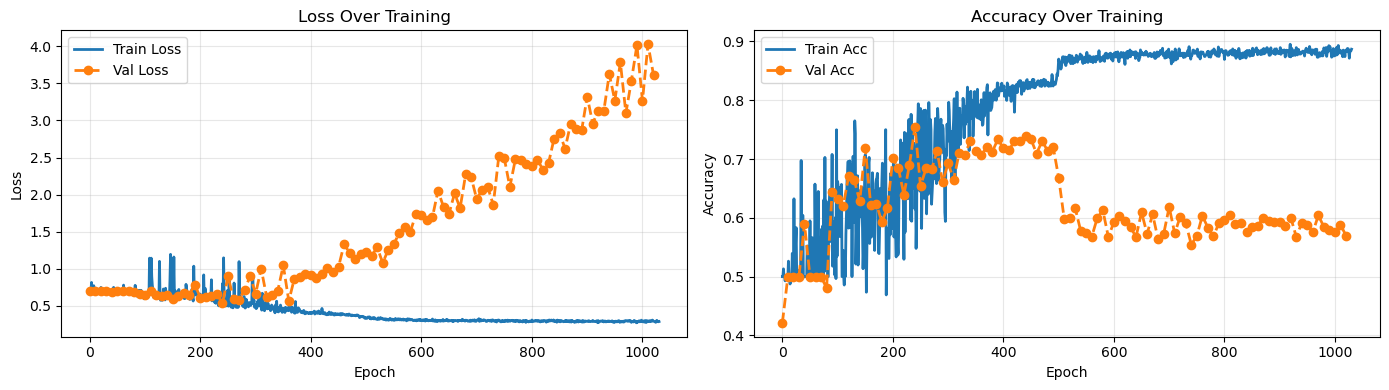


=== TRAINING SUMMARY ===
Final train loss: 0.284727
Final val loss: 3.615153
Best val loss: 0.530881


In [25]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))

# Plot losses
ax1.plot(train_losses, label='Train Loss', linewidth=2)
if val_losses:
    val_epochs = list(range(0, len(train_losses), config_dict['val_interval']))[:len(val_losses)]
    ax1.plot(val_epochs, val_losses, '--', label='Val Loss', linewidth=2, marker='o')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.set_title('Loss Over Training')
ax1.grid(True, alpha=0.3)
ax1.legend()

# Plot accuracy
ax2.plot(train_accs, label='Train Acc', linewidth=2)
if val_accs:
    val_epochs = list(range(0, len(train_losses), config_dict['val_interval']))[:len(val_accs)]
    ax2.plot(val_epochs, val_accs, '--', label='Val Acc', linewidth=2, marker='o')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy')
ax2.set_title('Accuracy Over Training')
ax2.grid(True, alpha=0.3)
ax2.legend()

plt.tight_layout()
plt.show()

print(f"\n=== TRAINING SUMMARY ===")
print(f"Final train loss: {train_losses[-1]:.6f}")
if val_losses:
    print(f"Final val loss: {val_losses[-1]:.6f}")
print(f"Best val loss: {best_loss:.6f}")

In [26]:
## Reconstruction Visualization - Ground Truth vs Prediction

model.eval()
with torch.no_grad():
    sample = train_dataset[0]
    query_points = sample['query_points'].unsqueeze(0).to(device)
    occ_gt = sample['occupancy'].unsqueeze(0).to(device)
    
    inputs = torch.empty(query_points.size(0), 0, device=device)
    c = model.encode_inputs(inputs)
    q_z = model.infer_z(query_points, occ_gt, c)
    z = q_z.rsample()
    logits = model.decode(query_points, z, c).logits
    occ_pred = torch.sigmoid(logits)

occ_gt_np = occ_gt.squeeze().cpu().numpy()
occ_pred_np = occ_pred.squeeze().cpu().numpy()
query_points_np = query_points.squeeze().cpu().numpy()

# Use adaptive threshold based on quantiles
gt_threshold = np.quantile(occ_gt_np, 0.5)
pred_threshold = np.quantile(occ_pred_np, 0.5)

gt_mask = occ_gt_np > gt_threshold
pred_mask = occ_pred_np > pred_threshold

print(f"GT threshold: {gt_threshold:.4f}, GT points: {gt_mask.sum()}")
print(f"Pred threshold: {pred_threshold:.4f}, Pred points: {pred_mask.sum()}")

# Ground Truth Plot
fig1 = go.Figure(data=[go.Scatter3d(x=query_points_np[gt_mask, 0], y=query_points_np[gt_mask, 1], 
                                     z=query_points_np[gt_mask, 2], mode='markers',
                                     marker=dict(size=2, color='blue'))])
fig1.update_layout(title='Ground Truth', scene_aspectmode='data', width=700, height=600)
fig1.show()

# Reconstruction Plot
fig2 = go.Figure(data=[go.Scatter3d(x=query_points_np[pred_mask, 0], y=query_points_np[pred_mask, 1], 
                                     z=query_points_np[pred_mask, 2], mode='markers',
                                     marker=dict(size=2, color='red'))])
fig2.update_layout(title='Reconstruction', scene_aspectmode='data', width=700, height=600)
fig2.show()

GT threshold: 0.5000, GT points: 5000
Pred threshold: 0.7525, Pred points: 5000


In [27]:
model.eval()

N_QUERY = 10000

# Dense random query grid in [-0.5, 0.5]^3 for visualization
query_grid = (torch.rand(N_QUERY, 3) - 0.5).to(device)

with torch.no_grad():
    # Infer z from training sample using posterior
    sample = train_dataset[0]
    query_train = sample['query_points'].unsqueeze(0).to(device)
    occ_gt = sample['occupancy'].unsqueeze(0).to(device)
    c = torch.empty(1, 0, device=device)
    q_z = model.infer_z(query_train, occ_gt, c)
    z = q_z.mean  # posterior mean — no sampling noise

    # Decode the visualization grid with this z
    logits = model.decode(query_grid.unsqueeze(0), z, c).logits  # (1, N_QUERY)
    probs = torch.sigmoid(logits).squeeze(0)                      # (N_QUERY,)

query_np = query_grid.cpu().numpy()
probs_np = probs.cpu().numpy()
gt_centroids, _ = train_dataset.get_centroid_points(0)

mask = probs_np > 0.5
print(f"Occupied points (prob > 0.5): {mask.sum()} / {N_QUERY}")
print(f"Mean prob: {probs_np.mean():.4f}, Posterior KL: {dist.kl_divergence(q_z, model.p0_z).sum(-1).mean().item():.2f}")

fig = make_subplots(
    rows=1, cols=2,
    specs=[[{'type': 'scatter3d'}, {'type': 'scatter3d'}]],
    subplot_titles=['GT Centroids', 'Decoded (posterior mean z)'],
)

fig.add_trace(go.Scatter3d(
    x=gt_centroids[:, 0], y=gt_centroids[:, 1], z=gt_centroids[:, 2],
    mode='markers', marker=dict(size=3, color='royalblue'), showlegend=False,
), row=1, col=1)

fig.add_trace(go.Scatter3d(
    x=query_np[mask, 0], y=query_np[mask, 1], z=query_np[mask, 2],
    mode='markers', marker=dict(size=2, color='tomato', opacity=0.7), showlegend=False,
), row=1, col=2)

fig.update_layout(title='Occupancy Decoding — posterior mean z', width=1200, height=600)
fig.update_scenes(aspectmode='data', row=1, col=1)
fig.update_scenes(aspectmode='data', row=1, col=2)
fig.show()

Occupied points (prob > 0.5): 2048 / 10000
Mean prob: 0.1878, Posterior KL: 382.12
